# Module 2 — Probability Foundations

**Statistics Deep Dive · Notebook 2 of 13**

Statistics runs on probability the way physics runs on calculus. Every p-value, confidence interval and posterior distribution you will meet later is "just" a probability statement. This module builds the toolkit — with pictures and simulations instead of measure theory.

### 🎯 Learning goals
1. Explain what a probability *is* (three interpretations) and compute with events using set operations.
2. Apply the complement, addition and multiplication rules.
3. Compute **conditional probabilities**, test **independence**, and avoid the prosecutor's fallacy.
4. Use the **law of total probability** and **Bayes' theorem** — with natural frequencies and icon arrays.
5. Work with **random variables**: expectation, variance, covariance and their calculation rules.
6. Use **Monte Carlo simulation** to solve problems that are painful analytically.

### 🗺️ Contents
1. What is probability? · 2. Events & Venn diagrams · 3. The three rules · 4. Conditional probability · 5. Independence · 6. Bayes' theorem · 7. Random variables, E[X], Var[X] · 8. Two famous puzzles · 9. Monte Carlo · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

---
## 1. What is probability?

A probability is a number between 0 and 1 attached to an **event**. There are three ways to read that number:

| Interpretation | "P(heads) = 0.5" means … | Used when |
|---|---|---|
| **Classical** | 1 of 2 *equally likely* outcomes is favourable | dice, cards, lotteries |
| **Frequentist** | in a long series of flips the *relative frequency* of heads approaches 0.5 | repeatable experiments, quality control, clinical trials |
| **Bayesian / subjective** | my *degree of belief* that the next flip shows heads is 50 % | one-off events ("P(recession next year)"), updating beliefs with data (Module 12) |

All three obey the same mathematics — **Kolmogorov's axioms**: (1) $P(A) \ge 0$, (2) $P(\Omega) = 1$, (3) for mutually exclusive events $P(A \cup B) = P(A) + P(B)$. Everything else in this notebook is a consequence of these three lines.

### The frequentist picture: probability as long-run frequency

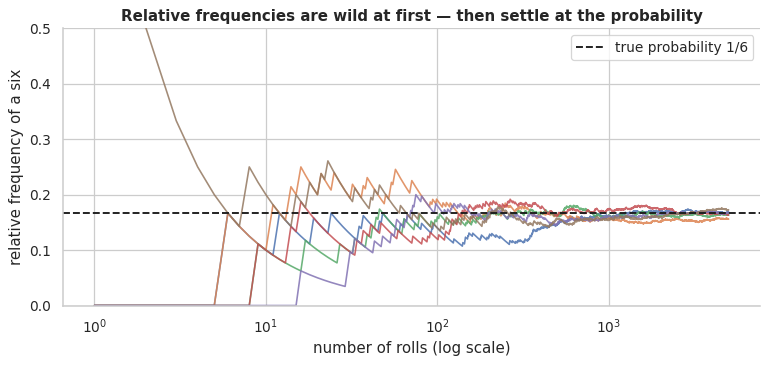

In [2]:
n = 5000
fig, ax = plt.subplots(figsize=(10, 4))
for k in range(6):                                           # six independent series of die rolls
    six = rng.integers(1, 7, n) == 6
    ax.plot(np.arange(1, n + 1), six.cumsum() / np.arange(1, n + 1), lw=1.3, alpha=.85)
ax.axhline(1 / 6, color="k", ls="--", label="true probability 1/6")
ax.set(xscale="log", ylim=(0, .5), xlabel="number of rolls (log scale)", ylabel="relative frequency of a six",
       title="Relative frequencies are wild at first — then settle at the probability")
ax.legend(); plt.show()

After 10 rolls the six series disagree wildly; after 5000 they are indistinguishable. This stabilisation is the **law of large numbers** (Module 4) — and it is the reason casinos and insurers are profitable businesses rather than gamblers.

---
## 2. Sample spaces, events and Venn diagrams

* **Sample space** $\Omega$: the set of all possible outcomes (die: $\{1,\dots,6\}$).
* **Event** $A \subseteq \Omega$: a set of outcomes ("even number" $=\{2,4,6\}$).
* Events combine like sets: **union** $A \cup B$ ("A *or* B"), **intersection** $A \cap B$ ("A *and* B"), **complement** $A^c$ ("not A").
* $A$ and $B$ are **mutually exclusive (disjoint)** if $A \cap B = \emptyset$ — they cannot happen together.

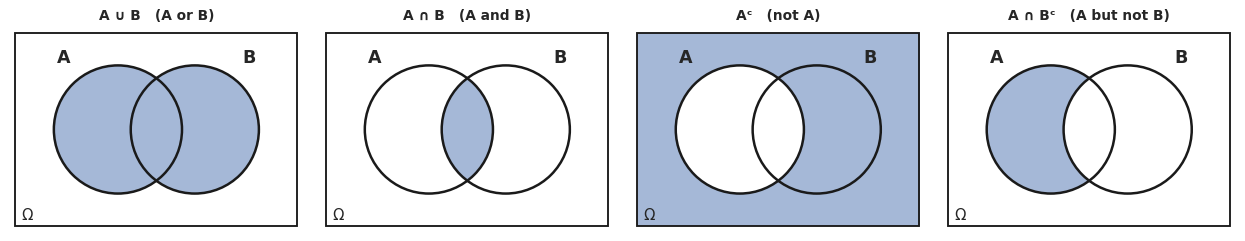

In [3]:
def venn(ax, region, title):
    xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 500), np.linspace(-1.5, 1.5, 350))
    A, B = (xx + .6) ** 2 + yy ** 2 < 1, (xx - .6) ** 2 + yy ** 2 < 1
    ax.contourf(xx, yy, region(A, B).astype(float), levels=[.5, 1.5], colors=[C[0]], alpha=.5)
    for cx, lab in [(-.6, "A"), (.6, "B")]:
        ax.add_patch(plt.Circle((cx, 0), 1, fill=False, lw=2, ec="k")); ax.text(cx * 2.4, 1.05, lab, fontsize=14, fontweight="bold", ha="center")
    ax.add_patch(plt.Rectangle((-2.2, -1.5), 4.4, 3, fill=False, lw=1.5, ec="k")); ax.text(-2.1, -1.4, "Ω", fontsize=12)
    ax.set(aspect="equal", xlim=(-2.3, 2.3), ylim=(-1.6, 1.6)); ax.set_title(title, fontsize=11); ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
venn(axes[0], lambda A, B: A | B,  "A ∪ B   (A or B)")
venn(axes[1], lambda A, B: A & B,  "A ∩ B   (A and B)")
venn(axes[2], lambda A, B: ~A,     "Aᶜ   (not A)")
venn(axes[3], lambda A, B: A & ~B, "A ∩ Bᶜ   (A but not B)")
plt.tight_layout(); plt.show()

**💡 Think of probability as area.** If $\Omega$ has area 1, then $P(A)$ is simply the area of $A$. Every rule below is then obvious from the picture.

---
## 3. The three calculation rules

| Rule | Formula | Picture | Example |
|---|---|---|---|
| **Complement** | $P(A^c) = 1 - P(A)$ | everything outside the circle | P(at least one defect) = 1 − P(no defect) — *the single most useful trick in probability* |
| **Addition** | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ | adding both circles counts the overlap twice | P(customer buys coffee or cake) |
| **Multiplication** | $P(A \cap B) = P(A)\cdot P(B \mid A)$ | first restrict to $A$, then take the $B$-share inside it | P(two aces in a row) $= \frac{4}{52}\cdot\frac{3}{51}$ |

**Worked example (complement rule).** A production line produces 2 % defective parts. What is the probability that a box of 50 contains *at least one* defective part? Counting all the ways to have 1, 2, 3 … defects is painful; the complement is one line: $1 - 0.98^{50}$.

In [4]:
p_defect, n_box = 0.02, 50
exact = 1 - (1 - p_defect) ** n_box
sim = (rng.random((200_000, n_box)) < p_defect).any(axis=1).mean()
print(f"P(at least one defective part in a box of {n_box}) = {exact:.4f}   (simulation with 200,000 boxes: {sim:.4f})")

P(at least one defective part in a box of 50) = 0.6358   (simulation with 200,000 boxes: 0.6347)


---
## 4. Conditional probability — shrinking the universe

$$P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

"Given that $A$ happened" means: **throw away everything outside $A$** and re-normalise. $A$ becomes the new universe.

**Example (telecom churn).** 60 % of customers have a *monthly* contract, 40 % an *annual* one. Within one year 30 % of the monthly but only 8 % of the annual customers cancel ("churn"). The **mosaic plot** below encodes this: column widths are $P(\text{contract})$, the red share *within each column* is $P(\text{churn} \mid \text{contract})$, and each tile's **area** is a joint probability.

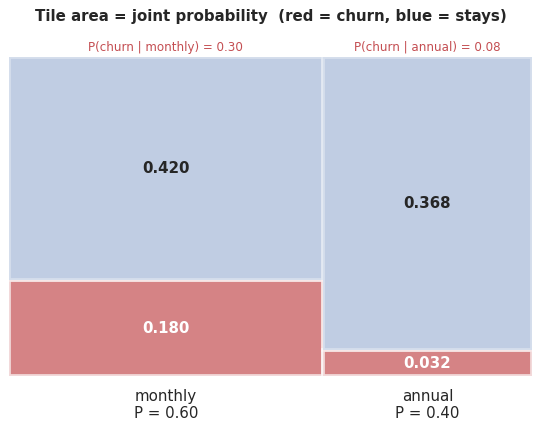

P(churn)            = 0.180 + 0.032 = 0.212     <- law of total probability: add the red tiles
P(monthly | churn)  = 0.180 / 0.212 = 0.849     <- Bayes: share of the red area that sits in the 'monthly' column


In [5]:
def mosaic(ax, pA, pB_A, pB_notA, names, title):
    x0 = 0
    for w, pb, name in [(pA, pB_A, names[0]), (1 - pA, pB_notA, names[1])]:
        ax.add_patch(plt.Rectangle((x0, 0), w, pb, color=C[3], alpha=.7, ec="w", lw=3))
        ax.add_patch(plt.Rectangle((x0, pb), w, 1 - pb, color=C[0], alpha=.35, ec="w", lw=3))
        ax.text(x0 + w / 2, pb / 2, f"{w * pb:.3f}", ha="center", va="center", fontweight="bold", color="w")
        ax.text(x0 + w / 2, pb + (1 - pb) / 2, f"{w * (1 - pb):.3f}", ha="center", va="center", fontweight="bold")
        ax.text(x0 + w / 2, -.04, f"{name}\nP = {w:.2f}", ha="center", va="top")
        ax.text(x0 + w / 2, 1.02, f"P(churn | {name}) = {pb:.2f}", ha="center", fontsize=9.5, color=C[3])
        x0 += w
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[]); ax.set_title(title, y=1.09)
    for s in ax.spines.values(): s.set_visible(False)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
mosaic(ax, .6, .30, .08, ["monthly", "annual"], "Tile area = joint probability  (red = churn, blue = stays)")
plt.show()

p_churn = .6 * .30 + .4 * .08
print(f"P(churn)            = 0.180 + 0.032 = {p_churn:.3f}     <- law of total probability: add the red tiles")
print(f"P(monthly | churn)  = 0.180 / {p_churn:.3f} = {.18 / p_churn:.3f}     <- Bayes: share of the red area that sits in the 'monthly' column")

Two things to notice:

* **Law of total probability:** $P(B) = \sum_i P(B \mid A_i)\,P(A_i)$ — add up the red tiles over all columns.
* $P(\text{churn} \mid \text{monthly}) = 0.30$ but $P(\text{monthly} \mid \text{churn}) = 0.85$. **$P(B \mid A) \neq P(A \mid B)$.** Confusing the two is known as the *prosecutor's fallacy*: "the probability of this DNA match if the defendant were innocent is 1 in a million" is **not** "the probability that the defendant is innocent is 1 in a million".

---
## 5. Independence

$A$ and $B$ are **independent** if knowing one tells you nothing about the other:

$$P(B \mid A) = P(B) \quad\Longleftrightarrow\quad P(A \cap B) = P(A)\,P(B)$$

In a mosaic plot independence means the red/blue split is **at the same height in every column**.

> ⚠️ *Independent* ≠ *mutually exclusive*. Mutually exclusive events are maximally **dependent**: if $A$ happened, $B$ certainly did not.

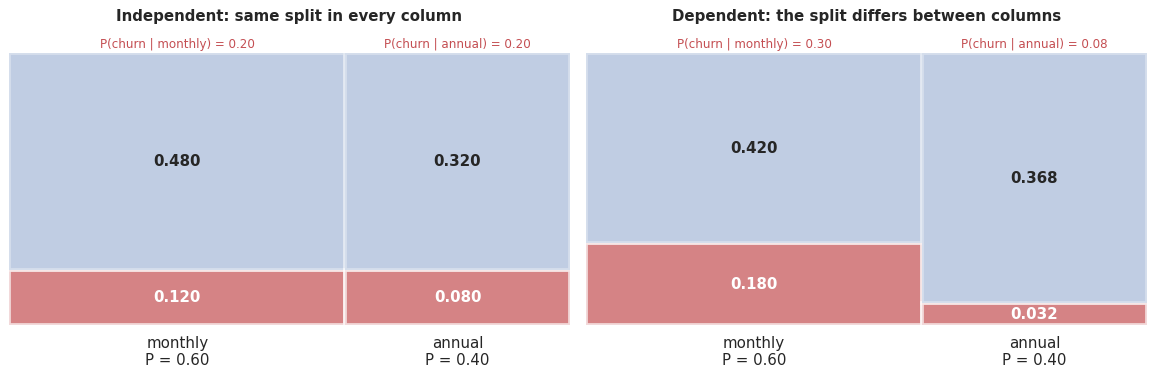

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
mosaic(axes[0], .6, .20, .20, ["monthly", "annual"], "Independent: same split in every column")
mosaic(axes[1], .6, .30, .08, ["monthly", "annual"], "Dependent: the split differs between columns")
plt.tight_layout(); plt.show()

Independence is the assumption behind almost every formula in classical statistics ("i.i.d. = independent and identically distributed"). It is also the assumption that fails most often in practice: measurements from the same patient, sales on consecutive days, students in the same class — none of these are independent.

---
## 6. Bayes' theorem — reasoning backwards from evidence

$$P(H \mid E) = \frac{P(E \mid H)\,P(H)}{P(E)} = \frac{P(E \mid H)\,P(H)}{P(E \mid H)P(H) + P(E \mid H^c)P(H^c)}$$

| Term | Name | In a medical test |
|---|---|---|
| $P(H)$ | **prior** | prevalence of the disease |
| $P(E \mid H)$ | **likelihood** | sensitivity (true-positive rate) |
| $P(E \mid H^c)$ | false-positive rate | 1 − specificity |
| $P(H \mid E)$ | **posterior** | positive predictive value (PPV): P(ill \| test positive) |

**The classic surprise.** A disease has 1 % prevalence. A test detects 90 % of the ill (sensitivity) and wrongly alarms 9 % of the healthy (specificity 91 %). You test positive.

> 🤔 **Predict first:** how likely is it that you are ill? 90 %? 50 %? Write down your guess, then run the cell.

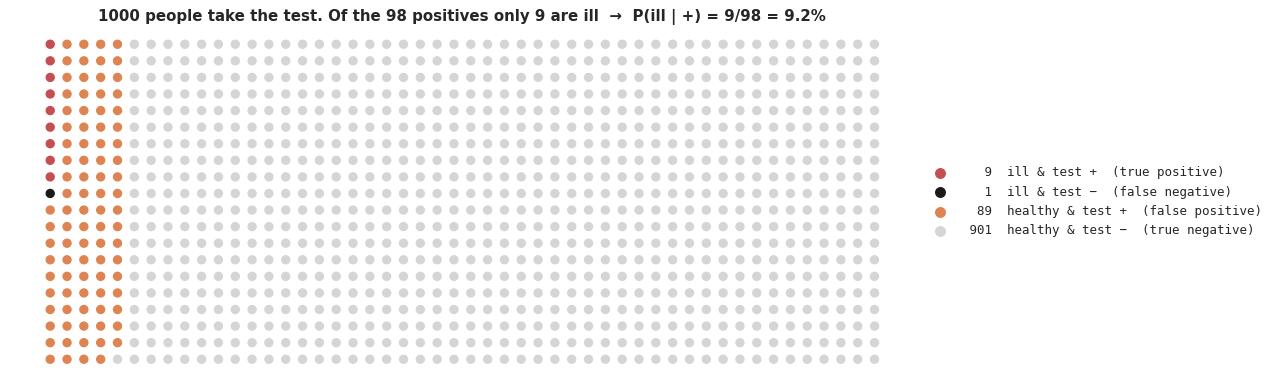

In [7]:
n, prev, sens, spec = 1000, .01, .90, .91
ill = int(n * prev); TP = round(ill * sens); FN = ill - TP; FP = round((n - ill) * (1 - spec)); TN = n - ill - FP
groups = [("ill & test +  (true positive)", TP, C[3]), ("ill & test −  (false negative)", FN, "k"),
          ("healthy & test +  (false positive)", FP, C[1]), ("healthy & test −  (true negative)", TN, "#d5d5d5")]
colors = sum([[col] * k for _, k, col in groups], [])
cols, rows = np.divmod(np.arange(n), 20)

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(cols, rows, c=colors, s=42)
for name, k, col in groups: ax.scatter([], [], color=col, s=60, label=f"{k:>4}  {name}")
ax.legend(loc="center left", bbox_to_anchor=(1, .5), frameon=False, prop={"family": "monospace", "size": 10})
ax.set_title(f"1000 people take the test. Of the {TP + FP} positives only {TP} are ill  →  P(ill | +) = {TP}/{TP + FP} = {TP / (TP + FP):.1%}")
ax.axis("off"); ax.invert_yaxis(); plt.show()

**Why intuition fails:** we focus on the 90 % sensitivity and forget the **base rate**. Because healthy people outnumber ill people 99 : 1, even a modest false-positive rate produces far more false alarms (orange) than true positives (red). The same calculation as a **natural-frequency tree** — the format in which doctors (and everybody else) make the fewest errors:

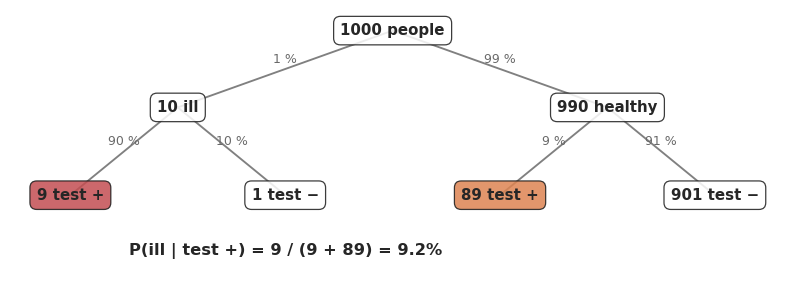

In [8]:
nodes = {"all": (.5, .9, "1000 people"), "ill": (.22, .55, f"{ill} ill"), "ok": (.78, .55, f"{n - ill} healthy"),
         "TP": (.08, .15, f"{TP} test +"), "FN": (.36, .15, f"{FN} test −"), "FP": (.64, .15, f"{FP} test +"), "TN": (.92, .15, f"{TN} test −")}
edges = [("all", "ill", "1 %"), ("all", "ok", "99 %"), ("ill", "TP", "90 %"), ("ill", "FN", "10 %"), ("ok", "FP", "9 %"), ("ok", "TN", "91 %")]
fig, ax = plt.subplots(figsize=(11, 3.8))
for a, b, lab in edges:
    (x1, y1, _), (x2, y2, _) = nodes[a], nodes[b]
    ax.plot([x1, x2], [y1, y2], color="grey", zorder=1); ax.text((x1 + x2) / 2, (y1 + y2) / 2 + .03, lab, ha="center", fontsize=10, color="dimgrey")
for k, (x, y, lab) in nodes.items():
    fc = {"TP": C[3], "FP": C[1]}.get(k, "white")
    ax.text(x, y, lab, ha="center", va="center", fontsize=12, fontweight="bold", bbox=dict(boxstyle="round,pad=.45", fc=fc, ec="k", alpha=.85))
ax.text(.36, -.12, f"P(ill | test +) = {TP} / ({TP} + {FP}) = {TP / (TP + FP):.1%}", fontsize=13, fontweight="bold", ha="center")
ax.set(xlim=(0, 1), ylim=(-.2, 1)); ax.axis("off"); plt.show()

### The base rate drives everything
The same test is nearly useless for mass screening of a rare disease, yet excellent in a clinic where patients already have symptoms (prior = 30 %). The plot shows the PPV as a function of prevalence for three levels of specificity.

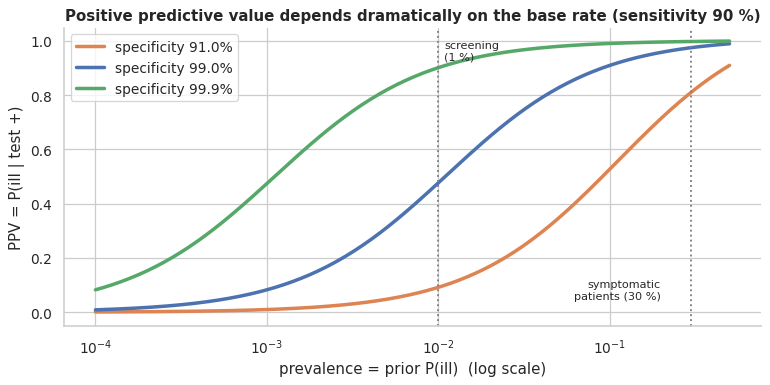

In [9]:
prev_grid = np.logspace(-4, -.3, 300)
fig, ax = plt.subplots(figsize=(10, 4.3))
for sp, col in zip([.91, .99, .999], [C[1], C[0], C[2]]):
    ppv = .9 * prev_grid / (.9 * prev_grid + (1 - sp) * (1 - prev_grid))
    ax.plot(prev_grid, ppv, lw=2.8, color=col, label=f"specificity {sp:.1%}")
ax.axvline(.01, color="grey", ls=":"); ax.text(.0108, .93, "screening\n(1 %)", fontsize=9)
ax.axvline(.30, color="grey", ls=":"); ax.text(.20, .05, "symptomatic\npatients (30 %)", fontsize=9, ha="right")
ax.set(xscale="log", xlabel="prevalence = prior P(ill)  (log scale)", ylabel="PPV = P(ill | test +)",
       title="Positive predictive value depends dramatically on the base rate (sensitivity 90 %)")
ax.legend(); plt.show()

---
## 7. Random variables, expectation and variance

A **random variable** $X$ assigns a number to every outcome (the *sum* of two dice, the *payout* of a policy, the *number* of defects). Its distribution is described by a **PMF** $p(x) = P(X = x)$ (discrete) or a **PDF** $f(x)$ (continuous) — see Module 3.

$$\mathbb{E}[X] = \sum_x x\,p(x) \qquad\qquad \operatorname{Var}(X) = \mathbb{E}\big[(X-\mu)^2\big] = \mathbb{E}[X^2] - \mu^2$$

* $\mathbb{E}[X]$ is the **probability-weighted average** — the balance point of the PMF and the long-run average over many repetitions. It need not be a value that can actually occur.
* $\operatorname{Var}(X)$ is the expected squared distance from $\mu$; $\sigma = \sqrt{\operatorname{Var}}$ is in the units of $X$.

**Example — a scratch card** costs €2 and pays €0 / €2 / €10 / €100 with probabilities 0.80 / 0.15 / 0.045 / 0.005.

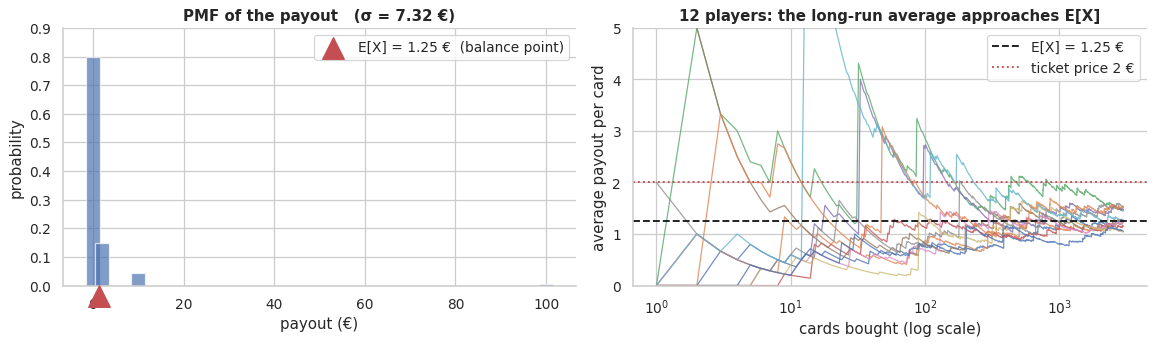

Expected payout 1.25 € per 2 € ticket -> the operator keeps 0.75 € per card on average (38%).


In [10]:
payout = np.array([0, 2, 10, 100.]); prob = np.array([.80, .15, .045, .005])
mu = (payout * prob).sum(); var = ((payout - mu) ** 2 * prob).sum()
wins = rng.choice(payout, size=(12, 3000), p=prob)                    # 12 players buy 3000 cards each

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.bar(payout, prob, width=3, color=C[0], alpha=.7)
a1.scatter([mu], [-.035], marker="^", s=300, color=C[3], clip_on=False, zorder=5, label=f"E[X] = {mu:.2f} €  (balance point)")
a1.set(xlabel="payout (€)", ylabel="probability", title=f"PMF of the payout   (σ = {np.sqrt(var):.2f} €)", ylim=(0, .9)); a1.legend()
a2.plot(np.arange(1, 3001), wins.cumsum(axis=1).T / np.arange(1, 3001)[:, None], lw=1, alpha=.8)
a2.axhline(mu, color="k", ls="--", label=f"E[X] = {mu:.2f} €"); a2.axhline(2, color=C[3], ls=":", label="ticket price 2 €")
a2.set(xscale="log", ylim=(0, 5), xlabel="cards bought (log scale)", ylabel="average payout per card", title="12 players: the long-run average approaches E[X]"); a2.legend()
plt.tight_layout(); plt.show()
print(f"Expected payout {mu:.2f} € per 2 € ticket -> the operator keeps {2 - mu:.2f} € per card on average ({(2 - mu) / 2:.0%}).")

### Calculation rules (memorise these — they are used on every page of statistics)

| Rule | Holds … |
|---|---|
| $\mathbb{E}[aX + b] = a\,\mathbb{E}[X] + b$ | always |
| $\mathbb{E}[X + Y] = \mathbb{E}[X] + \mathbb{E}[Y]$ | **always** — even for dependent variables (linearity of expectation) |
| $\operatorname{Var}(aX + b) = a^2 \operatorname{Var}(X)$ | always (shifting does not change spread; scaling enters squared) |
| $\operatorname{Var}(X \pm Y) = \operatorname{Var}(X) + \operatorname{Var}(Y) \pm 2\operatorname{Cov}(X, Y)$ | always |
| $\operatorname{Var}(X \pm Y) = \operatorname{Var}(X) + \operatorname{Var}(Y)$ | if $X, Y$ are independent (or merely uncorrelated) — **variances add, standard deviations do not** |
| $\operatorname{Var}(\bar X) = \sigma^2 / n$ | for $n$ independent observations → the famous $\sigma/\sqrt{n}$ |

**Covariance** $\operatorname{Cov}(X,Y) = \mathbb{E}[(X-\mu_X)(Y-\mu_Y)]$ measures whether $X$ and $Y$ move together. The picture below shows why it matters: the sum of two assets with *negative* covariance is much less risky than either one — the mathematical core of **diversification** and hedging.

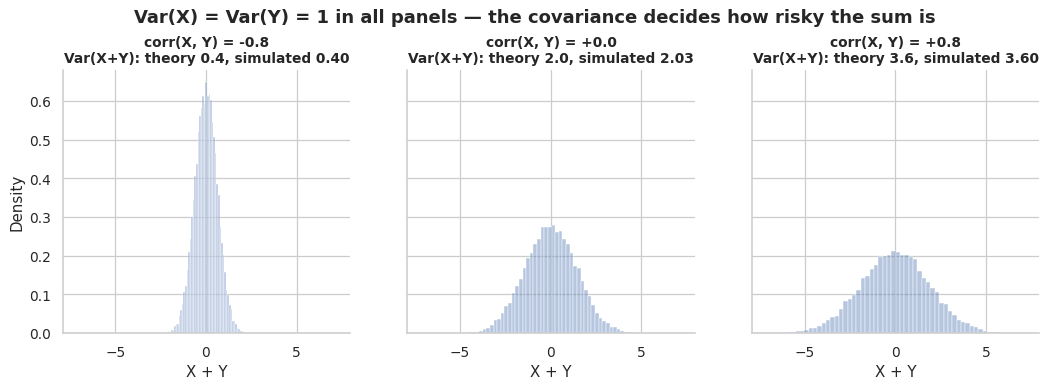

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
for ax, rho in zip(axes, [-.8, 0, .8]):
    xy = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], 20_000); total = xy.sum(axis=1)
    sns.histplot(total, bins=60, stat="density", ax=ax, color=C[0], alpha=.4)
    ax.set_title(f"corr(X, Y) = {rho:+.1f}\nVar(X+Y): theory {2 + 2 * rho:.1f}, simulated {total.var():.2f}", fontsize=11)
    ax.set_xlabel("X + Y")
fig.suptitle("Var(X) = Var(Y) = 1 in all panels — the covariance decides how risky the sum is", fontweight="bold", y=1.06); plt.show()

---
## 8. Two famous puzzles — settle them by simulation

### 8.1 The birthday problem
How many people must be in a room so that the probability that **at least two share a birthday** exceeds 50 %? (Complement rule: $P = 1 - \frac{365}{365}\cdot\frac{364}{365}\cdots\frac{365-k+1}{365}$.)

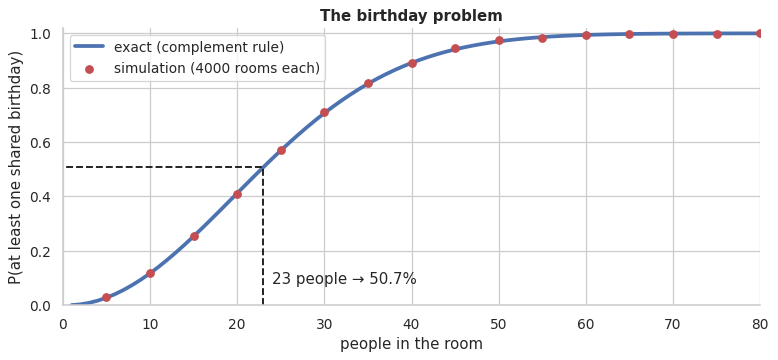

In [12]:
k = np.arange(1, 81)
p_exact = 1 - np.array([np.prod((365 - np.arange(kk)) / 365) for kk in k])
k_sim = np.arange(5, 81, 5)
p_sim = [np.mean([len(np.unique(rng.integers(0, 365, kk))) < kk for _ in range(4000)]) for kk in k_sim]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k, p_exact, lw=3, color=C[0], label="exact (complement rule)"); ax.scatter(k_sim, p_sim, color=C[3], zorder=3, label="simulation (4000 rooms each)")
ax.plot([23, 23, 0], [0, p_exact[22], p_exact[22]], color="k", ls="--"); ax.text(24, .08, f"23 people → {p_exact[22]:.1%}")
ax.set(xlabel="people in the room", ylabel="P(at least one shared birthday)", title="The birthday problem", xlim=(0, 80), ylim=(0, 1.02)); ax.legend(); plt.show()

Only **23** people are needed — because there are $\binom{23}{2} = 253$ *pairs*, each a chance for a match. The same mathematics governs hash collisions in computer science and "surprising coincidences" in data mining: with enough comparisons, coincidences are guaranteed.

### 8.2 The Monty Hall problem
Three doors, one car. You pick a door; the host — who knows where the car is — opens another door with a goat and offers you to switch. Should you?

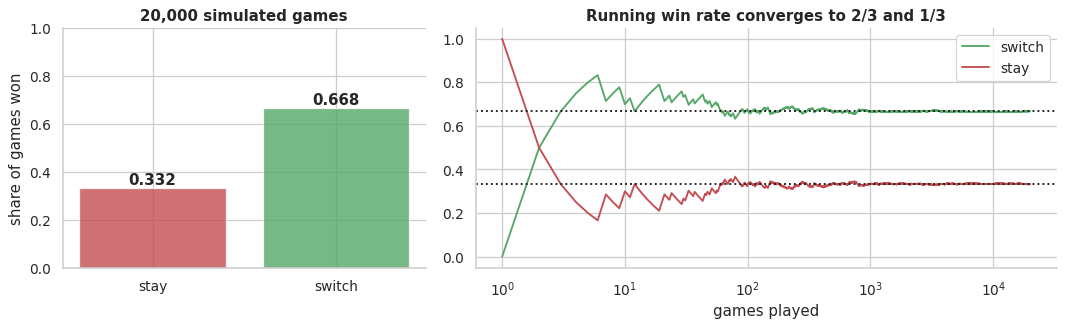

In [13]:
n_games = 20_000
car, pick = rng.integers(0, 3, n_games), rng.integers(0, 3, n_games)
win_stay = car == pick                      # staying wins iff the first pick was right
win_switch = ~win_stay                      # the host removes the only other goat -> switching wins iff the first pick was wrong

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.6]})
a1.bar(["stay", "switch"], [win_stay.mean(), win_switch.mean()], color=[C[3], C[2]], alpha=.8)
for i, v in enumerate([win_stay.mean(), win_switch.mean()]): a1.text(i, v + .015, f"{v:.3f}", ha="center", fontweight="bold")
a1.set(ylim=(0, 1), ylabel="share of games won", title=f"{n_games:,} simulated games")
g = np.arange(1, n_games + 1)
a2.plot(g, win_switch.cumsum() / g, color=C[2], label="switch"); a2.plot(g, win_stay.cumsum() / g, color=C[3], label="stay")
a2.axhline(2 / 3, color="k", ls=":"); a2.axhline(1 / 3, color="k", ls=":")
a2.set(xscale="log", xlabel="games played", title="Running win rate converges to 2/3 and 1/3"); a2.legend(); plt.tight_layout(); plt.show()

**Why 2/3?** Your first pick is right with probability 1/3. The host's action never changes that. So with probability 2/3 the car is behind "one of the other two doors" — and the host kindly shows you *which* of those two it is not. This is Bayes' theorem in disguise: the host's choice is *evidence* because it depends on where the car is.

---
## 9. Monte Carlo simulation — probability by brute force

Whenever a probability is an **expected value of something you can simulate**, you can estimate it by averaging simulated outcomes. The error shrinks like $1/\sqrt{n}$ (Module 4), *regardless* of how complicated the problem is. Toy example: estimate $\pi$ from the share of random points that fall inside the quarter circle, $P(\text{inside}) = \pi/4$.

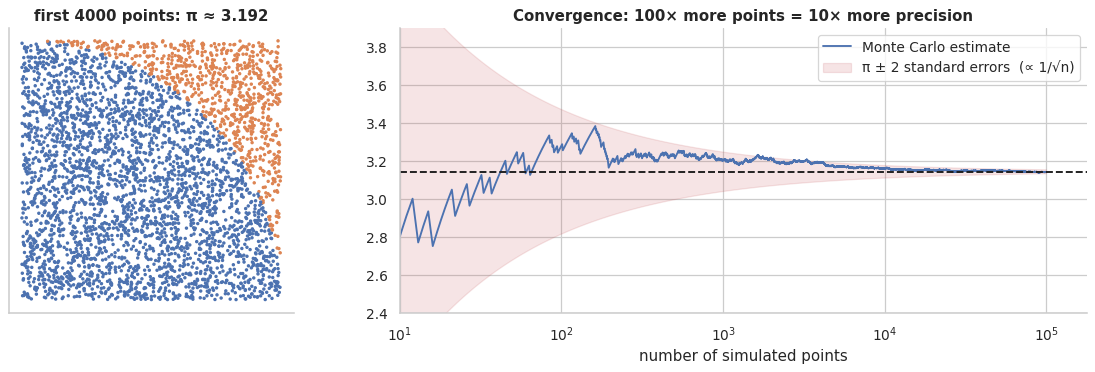

In [14]:
pts = rng.random((100_000, 2)); inside = (pts ** 2).sum(axis=1) < 1
n_run = np.arange(1, len(pts) + 1); est = 4 * inside.cumsum() / n_run

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.7]})
a1.scatter(*pts[:4000].T, c=[C[0] if i else C[1] for i in inside[:4000]], s=3); a1.set(aspect="equal", title=f"first 4000 points: π ≈ {est[3999]:.3f}", xticks=[], yticks=[])
a2.plot(n_run, est, color=C[0], label="Monte Carlo estimate")
se = 4 * np.sqrt(np.pi / 4 * (1 - np.pi / 4) / n_run)
a2.fill_between(n_run, np.pi - 2 * se, np.pi + 2 * se, color=C[3], alpha=.15, label="π ± 2 standard errors  (∝ 1/√n)")
a2.axhline(np.pi, color="k", ls="--")
a2.set(xscale="log", xlim=(10, None), ylim=(2.4, 3.9), xlabel="number of simulated points", title="Convergence: 100× more points = 10× more precision"); a2.legend()
plt.tight_layout(); plt.show()

---
## 10. Exercises — real-world use cases

### ✍️ Exercise 2.1 — *Bayes' theorem*: Build a tiny spam filter (email security)

You have 10,000 labelled e-mails with two binary features: does the mail contain the word **"free"**, does it contain the word **"meeting"**?

**Tasks**
1. Estimate from the data: $P(\text{spam})$, $P(\text{free} \mid \text{spam})$, $P(\text{free} \mid \text{ham})$.
2. Use **Bayes' theorem** to compute $P(\text{spam} \mid \text{free})$. Verify your result by computing the conditional relative frequency directly.
3. A mail contains *both* "free" and "meeting". Assuming the words are conditionally independent given the class (*naive Bayes*), compute $P(\text{spam} \mid \text{free}, \text{meeting})$. Compare with the direct frequency. What does the word "meeting" do to the evidence?
4. Are "free" and "meeting" independent in the *whole* data set? Check $P(A \cap B)$ vs $P(A)P(B)$ and explain.

In [15]:
g = np.random.default_rng(201)
spam = g.random(10_000) < 0.40
mails = pd.DataFrame({"spam": spam,
                      "free":    np.where(spam, g.random(10_000) < .30, g.random(10_000) < .02),
                      "meeting": np.where(spam, g.random(10_000) < .01, g.random(10_000) < .15)})
mails.head()

,spam,free,meeting
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/02_probability_foundations_solutions.ipynb`.

### ✍️ Exercise 2.2 — *Probability rules*: How reliable is the server rack? (Reliability engineering)

A small data-centre rack works if **all three subsystems** work during a year:

* **Power:** two redundant power supplies (rack works if *at least one* works); each survives the year with probability 0.95.
* **Network:** a single switch, survival probability 0.99.
* **Storage:** RAID with three disks, works if *at least two of three* disks survive; each disk survives with probability 0.90.

Assume all components fail independently.

**Tasks**
1. Compute the reliability of each subsystem and of the whole rack analytically (complement + multiplication rule).
2. Verify by simulating 1,000,000 rack-years.
3. You have budget for one upgrade: (a) a third power supply, (b) a second redundant switch, (c) better disks (0.97 each). Which one improves rack reliability the most?
4. Why might the independence assumption be dangerously optimistic here?

In [17]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/02_probability_foundations_solutions.ipynb`.

### ✍️ Exercise 2.3 — *Base rates*: Why does the fraud team drown in false alarms? (Banking)

A bank processes 1,000,000 card transactions per day; **0.2 %** are fraudulent. A new ML model flags **98 %** of fraudulent transactions (sensitivity) and raises a false alarm on **1 %** of legitimate ones.

**Tasks**
1. Of all flagged transactions, what fraction is actually fraud (PPV)? How many alerts per day must analysts review, and how many of them are real?
2. Draw the PPV as a function of the false-alarm rate (from 0.01 % to 5 %).
3. What false-alarm rate is needed so that at least every second alert is real fraud?
4. The flagged transactions are sent through a **second, independent** check with the same error rates. What is the PPV after two positive flags?

In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/02_probability_foundations_solutions.ipynb`.

### ✍️ Exercise 2.4 — *Expectation & variance*: Pricing an extended warranty (Retail / insurance)

An electronics retailer sells a 2-year extended warranty for **€89** on a €600 laptop. Historical claim data per laptop:

| Event | no claim | minor repair | major repair | total loss |
|---|---|---|---|---|
| cost to retailer | €0 | €120 | €350 | €600 |
| probability | 0.88 | 0.08 | 0.03 | 0.01 |

**Tasks**
1. Compute the expected claim cost and its standard deviation per warranty. What is the retailer's expected profit per warranty?
2. The retailer sells $n$ warranties (independent laptops). Give mean and standard deviation of the **total** profit for $n = 1,\ 100,\ 10{,}000$. How does the *relative* risk (std / mean) change with $n$?
3. Simulate the total profit for $n = 100$ and $n = 10{,}000$ (20,000 repetitions each) and plot both distributions of *profit per warranty*. Estimate P(loss) for both.
4. The customer's expected "loss" from buying is the retailer's expected profit. Can buying still be rational?

In [19]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/02_probability_foundations_solutions.ipynb`.

### ✍️ Exercise 2.5 — *Monte Carlo*: Will the project meet its deadline? (Project risk management)

A product launch consists of three **sequential** work packages. Experts give optimistic / most likely / pessimistic durations in working days (→ triangular distributions):

| Package | optimistic | most likely | pessimistic |
|---|---|---|---|
| Design | 10 | 14 | 25 |
| Development | 20 | 30 | 55 |
| Testing & certification | 8 | 10 | 20 |

In addition, there is a **20 % chance** that a supplier delivers late, adding a delay uniformly distributed between 5 and 15 days. The contractual deadline is **65 working days**.

**Tasks**
1. The "naive plan" adds the most-likely values. What does it predict?
2. Simulate 100,000 project runs. Plot the distribution of the total duration and mark the naive plan and the deadline.
3. Estimate P(deadline missed), the expected duration and the 80 % / 95 % quantiles ("P80 / P95 dates").
4. What deadline should the project manager commit to if she wants to be 90 % sure?

In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/02_probability_foundations_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* Probability = area. **Complement**, **addition** and **multiplication** rule follow from the picture.
* Conditioning = shrinking the universe. $P(A \mid B) \ne P(B \mid A)$ — mixing them up is the prosecutor's fallacy.
* **Independence** ($P(A\cap B)=P(A)P(B)$) is a strong assumption; common causes break it.
* **Bayes' theorem** turns $P(\text{evidence} \mid \text{hypothesis})$ into $P(\text{hypothesis} \mid \text{evidence})$. Never forget the **base rate**; use natural frequencies to stay sane.
* $\mathbb{E}$ is linear — always. **Variances add** for independent variables → the $\sqrt{n}$ law behind insurance, diversification and the standard error.
* If you can simulate it, you can estimate it: **Monte Carlo** error falls like $1/\sqrt{n}$.

**Next:** Module 3 — the named probability distributions and when each one appears in the wild.